# F-SPDENO para $\Phi^4_1$ — Paso 1: cálculo de las *features* de Wick

Este notebook implementa el modelo **F-SPDENO** del paper *"Expanding the Chaos"* (Apéndice F.1), sobre el ground truth que ya generamos en `phi41_ground_truth.ipynb`.

El pipeline completo del modelo (Fig. 2 y Apéndice D del paper) es:

$$\underbrace{W(t,x)}_{\text{ruido } Q\text{-Browniano}} \;\xrightarrow{\text{Def. 1--2}}\; \underbrace{\eta(W)=\{\xi_\alpha\}_{|\alpha|\le M}}_{\text{features de Wick}} \;\xrightarrow{\text{FNO}}\; \underbrace{\{u_{\alpha,k}(x)\}}_{\text{coef. espaciales}} \;\xrightarrow{\text{base temporal } \phi_k(t)}\; \hat u(t,x)$$

**En este primer paso construimos la flecha del medio: de la trayectoria de ruido $W$ a las features de Wick $\xi_\alpha$.** Es la parte que carga *toda* la estocasticidad del problema; el resto (FNO + reconstrucción) es determinista.

La construcción tiene dos sub-pasos:

1. **Coordenadas gaussianas** $\xi_{m,j}$ (Definición 1): proyectamos el ruido sobre una base espacial (Karhunen–Loève) y una base temporal ortonormal $\{e_j\}$ de $L^2([0,T])$.
2. **Monomios de Wick** $\xi_\alpha$ (Definición 2): productos normalizados de polinomios de Hermite de las $\xi_{m,j}$.

En cada paso **verificamos numéricamente** las propiedades teóricas que el paper usa: que las $\xi_{m,j}$ son $\mathcal N(0,1)$ independientes, y que los $\xi_\alpha$ son ortonormales, $\mathbb E[\xi_\alpha\xi_\beta]=\delta_{\alpha\beta}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import count
from math import factorial
from numpy.polynomial.hermite_e import hermeval   # polinomios de Hermite probabilistas (He)

# --- Cargar el ruido Q-Browniano generado por el ground truth ---
data = np.load("phi41_train_Wmap.npz")
W     = data["W_train"]                 # (N, Nt+1, Nx): ruido ACUMULADO W(t,x)
dx    = float(data["dx"]); dt = float(data["dt"])
T     = float(data["T"]);  sigma = float(data["sigma"])
N, Ntp1, Nx = W.shape
Nt    = Ntp1 - 1
L     = 1.0
x     = np.arange(Nx) * dx              # grilla espacial (toro [0,1])
t_inc = np.arange(Nt) * dt              # extremo izq. de cada incremento temporal

# Incrementos del ruido:  dW^n(x) = W^{n+1}(x) - W^n(x)   ->  (N, Nt, Nx)
dW = np.diff(W, axis=1)

print(f"N={N}  Nt={Nt}  Nx={Nx}  dt={dt}  T={T}  sigma={sigma}")
print("W :", W.shape, " (ruido acumulado)")
print("dW:", dW.shape, " (incrementos: 'blancos' en tiempo, correlacionados en espacio)")

N=1000  Nt=50  Nx=128  dt=0.001  T=0.05  sigma=0.1
W : (1000, 51, 128)  (ruido acumulado)
dW: (1000, 50, 128)  (incrementos: 'blancos' en tiempo, correlacionados en espacio)


## Paso 1 — Coordenadas gaussianas $\xi_{m,j}$

La **Definición 1** del paper extrae de la trayectoria de ruido un conjunto numerable de gaussianas estándar independientes:

$$\xi_{m,j} \;=\; \int_0^T e_j(s)\,d\beta^{(m)}_s,$$

donde:

- $m$ indexa el **modo espacial** (las eigenfunciones $f_m$ de Karhunen–Loève del $Q$-Browniano). Para $\Phi^4_1$ el ruido se generó proyectando sobre $\phi_m(x)=\sqrt{2/L}\,\sin(m\pi x/L)$, así que esas *son* las $f_m$.
- $j$ indexa el **modo temporal** ($\{e_j\}$, base ortonormal de $L^2([0,T])$).
- $\beta^{(m)}$ es el Browniano escalar 1D del modo espacial $m$.

**Cómo lo calculamos a partir de los datos** (lo que hará el modelo: solo ve $W$, no las variables internas):

1. **Recuperar los incrementos modales** $\Delta\beta^{(m)}_n$ proyectando el ruido físico sobre la base espacial:
   $$\langle dW^n,\,\phi_m\rangle \;=\; \sigma\,\Delta\beta^{(m)}_n \quad\Longrightarrow\quad \Delta\beta^{(m)}_n = \tfrac{1}{\sigma}\langle dW^n,\phi_m\rangle.$$
2. **Proyectar en el tiempo** sobre $\{e_j\}$ (Itô discreto):
   $$\xi_{m,j} \;=\; \sum_{n=0}^{N_t-1} e_j(t_n)\,\Delta\beta^{(m)}_n.$$

Por la isometría de Itô, si $\{e_j\}$ es ortonormal en $L^2([0,T])$ entonces $\mathrm{Var}(\xi_{m,j})=\int_0^T e_j^2\,ds=1$ y las $\xi_{m,j}$ resultan $\mathcal N(0,1)$ **independientes**. Eso es lo que verificaremos.

In [ ]:
# ============== 1a. Base espacial KL: recuperar incrementos modales dbeta^{(m)} ==============
# El ruido se generó como  dW^n(x) = sigma * sum_m dbeta_n^{(m)} phi_m(x),
# con phi_m(x) = sqrt(2/L) sin(m pi x / L)  (ortonormales en L^2[0,L]).

S    = 2                                  # nº de modos espaciales usados para las features
m_sp = np.arange(1, S + 1)
phi  = np.sqrt(2.0 / L) * np.sin(np.outer(m_sp, np.pi * x / L))    # (S, Nx)

# Verificación: phi discretamente ortonormal en la grilla  ->  Gram ≈ I
print("Gram espacial <phi_m, phi_m'> dx  (≈ I):\n", np.round((phi @ phi.T) * dx, 4))

# Proyección  <dW^n, phi_m> dx = sigma * dbeta_n^{(m)}   ->  dbeta ≈ N(0, dt)
proj  = np.einsum("ink,mk->inm", dW, phi) * dx     # (N, Nt, S)
dbeta = proj / sigma                               # (N, Nt, S)

print(f"\nvar(dbeta) por modo = {np.round(dbeta.var(axis=(0,1)), 5)} <  (esperado dt = {dt})")
print("cov(dbeta)/dt  (≈ I, modos independientes):\n",
      np.round(np.cov(dbeta.reshape(-1, S).T) / dt, 3))

Gram espacial <phi_m, phi_m'> dx  (≈ I):
 [[ 1. -0.]
 [-0.  1.]]

var(dbeta) por modo = [0.001   0.00099]   (esperado dt = 0.001)
cov(dbeta)/dt  (≈ I, modos independientes):
 [[0.998 0.   ]
 [0.    0.99 ]]


Gram temporal <e_j, e_k> dt  (= I exacta por construcción):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


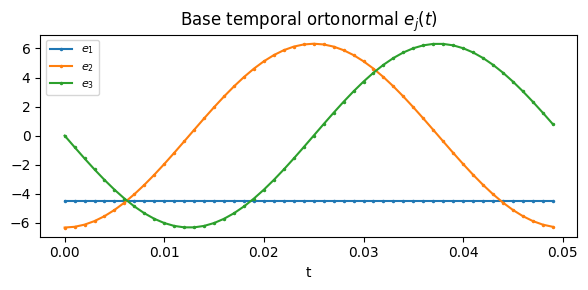

In [3]:
# ================== 1b. Base temporal ortonormal {e_j} en [0,T] ==================
# Necesitamos  sum_n e_j(t_n) e_k(t_n) dt = delta_jk  (ortonormalidad discreta).
# Partimos de funciones de Fourier y las ortonormalizamos exactamente con QR.

Tm  = 3                                   # nº de modos temporales
raw = [np.ones_like(t_inc)]               # e_1 ~ constante
for k in count(1):
    if len(raw) >= Tm:
        break
    raw.append(np.cos(2 * np.pi * k * t_inc / T))
    if len(raw) < Tm:
        raw.append(np.sin(2 * np.pi * k * t_inc / T))
Rmat = np.stack(raw, axis=1)              # (Nt, Tm)

# QR con el producto interno pesado por dt:  E^T E dt = I
Q, _ = np.linalg.qr(Rmat * np.sqrt(dt))   # Q^T Q = I
E    = Q / np.sqrt(dt)                     # (Nt, Tm)

print("Gram temporal <e_j, e_k> dt  (= I exacta por construcción):\n",
      np.round((E.T @ E) * dt, 6))

fig, ax = plt.subplots(figsize=(6, 3))
for j in range(Tm):
    ax.plot(t_inc, E[:, j], marker=".", ms=3, label=f"$e_{{{j+1}}}$")
ax.set_xlabel("t"); ax.set_title("Base temporal ortonormal $e_j(t)$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

D = S*Tm = 6 coordenadas gaussianas por trayectoria
media ≈ [ 0.011 -0.012  0.038 -0.021 -0.03   0.013]
var   ≈ [0.978 0.993 0.97  0.975 1.03  0.994]      (esperado 1)
||cov - I||_F = 0.1665   (→ 0 con más muestras)


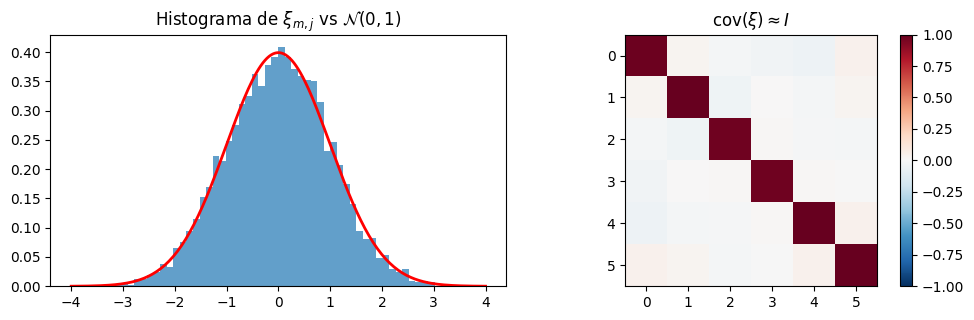

In [4]:
# ============ 1c. Coordenadas gaussianas xi_{m,j} y verificación N(0,1) iid ============
# xi_{m,j} = sum_n e_j(t_n) dbeta_n^{(m)}
xi      = np.einsum("nj,inm->imj", E, dbeta)   # (N, S, Tm)
D       = S * Tm                                # nº de coordenadas base gaussianas
xi_flat = xi.reshape(N, D)                      # (N, D)

cov = np.cov(xi_flat.T)
print(f"D = S*Tm = {D} coordenadas gaussianas por trayectoria")
print(f"media ≈ {np.round(xi_flat.mean(0), 3)}")
print(f"var   ≈ {np.round(xi_flat.var(0), 3)}      (esperado 1)")
print(f"||cov - I||_F = {np.linalg.norm(cov - np.eye(D)):.4f}   (→ 0 con más muestras)")

fig, axs = plt.subplots(1, 2, figsize=(10, 3.3))
axs[0].hist(xi_flat.ravel(), bins=60, density=True, alpha=.7)
zz = np.linspace(-4, 4, 200)
axs[0].plot(zz, np.exp(-zz**2 / 2) / np.sqrt(2 * np.pi), "r", lw=2)
axs[0].set_title(r"Histograma de $\xi_{m,j}$ vs $\mathcal{N}(0,1)$")
im = axs[1].imshow(cov, cmap="RdBu_r", vmin=-1, vmax=1)
axs[1].set_title(r"cov$(\xi)\approx I$"); fig.colorbar(im, ax=axs[1])
plt.tight_layout(); plt.show()

## Paso 2 — Monomios de Wick $\xi_\alpha$

La **Definición 2** combina las coordenadas gaussianas en una base ortonormal del espacio de variables aleatorias de cuadrado integrable. Un **multi-índice** $\alpha=(\alpha_{m,j})$ asigna un orden a cada coordenada, y el monomio de Wick normalizado es:

$$\xi_\alpha \;=\; \frac{1}{\sqrt{\alpha!}}\prod_{m,j} h_{\alpha_{m,j}}\!\big(\xi_{m,j}\big), \qquad \alpha! = \prod_{m,j}\alpha_{m,j}!,$$

donde $h_k$ es el **polinomio de Hermite probabilista** ($h_0{=}1,\ h_1{=}x,\ h_2{=}x^2{-}1,\ h_3{=}x^3{-}3x,\dots$).

La propiedad clave (Lema 3) es la **ortonormalidad**:
$$\mathbb E[\xi_\alpha\,\xi_\beta] = \delta_{\alpha\beta},$$
que se hereda de $\mathbb E[h_n(Z)h_k(Z)] = n!\,\delta_{nk}$ para $Z\sim\mathcal N(0,1)$ y de la independencia de las $\xi_{m,j}$.

**Truncamiento.** En la práctica nos quedamos con $|\alpha| = \sum_{m,j}\alpha_{m,j} \le M$. El paper reporta $M=4$ como óptimo para $\Phi^4_1$ (decaimiento factorial del caos, Remark 4). El nº de features es
$$\#\{\alpha : |\alpha|\le M\} = \binom{D+M}{M}, \qquad D = S\cdot T_m,$$
que crece rápido: es el *trade-off* central entre fidelidad ($S,T_m,M$ grandes) y costo.

In [5]:
# ================== 2. Multi-índices, Hermite y monomios de Wick ==================
M = 4                                     # orden de Hermite / caos (óptimo del paper)

def multi_indices(D, M):
    """Todos los multi-índices (a_1,...,a_D), a_d >= 0, con sum a_d <= M.
    El primero es (0,...,0) -> monomio constante xi_0 = 1."""
    res = []
    def rec(prefix, rem):
        if len(prefix) == D:
            res.append(tuple(prefix)); return
        for v in range(rem + 1):
            rec(prefix + [v], rem - v)
    rec([], M)
    return res

def hermite_he(k, xv):
    """h_k probabilista (HermiteE) evaluado en xv."""
    c = np.zeros(k + 1); c[k] = 1.0
    return hermeval(xv, c)

def wick_features(xi_flat, alphas, M):
    """Matriz (N, #alphas) de monomios de Wick normalizados xi_alpha."""
    N, D = xi_flat.shape
    H = np.empty((M + 1, N, D))           # H[k,i,d] = h_k(xi_flat[i,d])
    for k in range(M + 1):
        H[k] = hermite_he(k, xi_flat)
    out = np.empty((N, len(alphas)))
    for idx, a in enumerate(alphas):
        val = np.ones(N); afac = 1
        for d, ad in enumerate(a):
            if ad > 0:
                val = val * H[ad, :, d]; afac *= factorial(ad)
        out[:, idx] = val / np.sqrt(afac)
    return out

alphas = multi_indices(D, M)
print(f"D={D}, M={M}  ->  #features (|alpha|<=M) = {len(alphas)}  = C(D+M,M)")
print("primeros multi-índices:", alphas[:4])
print("último multi-índice    :", alphas[-1], " (|alpha| =", sum(alphas[-1]), ")")

D=6, M=4  ->  #features (|alpha|<=M) = 210  = C(D+M,M)
primeros multi-índices: [(0, 0, 0, 0, 0, 0), (0, 0, 0, 0, 0, 1), (0, 0, 0, 0, 0, 2), (0, 0, 0, 0, 0, 3)]
último multi-índice    : (4, 0, 0, 0, 0, 0)  (|alpha| = 4 )


matriz de features: (1000, 210)
[datos N=1000] diag media = 1.015  (esperado 1)
[datos] bloque |alpha|<=2 (28 feats): diag=0.992, max|offdiag|=0.166
[sintético N=  1000] max|offdiag| = 0.987
[sintético N= 20000] max|offdiag| = 0.400
[sintético N=200000] max|offdiag| = 0.092


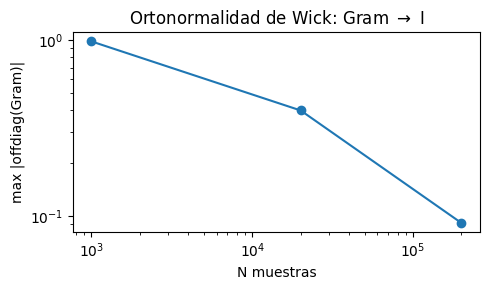

In [6]:
# ============ 3. Verificación de ortonormalidad  E[xi_a xi_b] ≈ delta_ab ============
Xi   = wick_features(xi_flat, alphas, M)        # (N, #features)
Gram = (Xi.T @ Xi) / N
print("matriz de features:", Xi.shape)
print(f"[datos N={N}] diag media = {np.diag(Gram).mean():.3f}  (esperado 1)")

# Bloque de orden bajo (|alpha|<=2): limpio incluso con N=1000.
# Los órdenes altos tienen colas pesadas -> el estimador empírico es ruidoso.
low = [i for i, a in enumerate(alphas) if sum(a) <= 2]
Gl  = Gram[np.ix_(low, low)]
print(f"[datos] bloque |alpha|<=2 ({len(low)} feats): diag={np.diag(Gl).mean():.3f}, "
      f"max|offdiag|={np.abs(Gl - np.diag(np.diag(Gl))).max():.3f}")

# La CONSTRUCCIÓN es exacta en el límite: con gaussianas sintéticas, Gram -> I.
rng = np.random.default_rng(0)
Ns, errs = [1000, 20000, 200000], []
for Nb in Ns:
    Z  = rng.standard_normal((Nb, D))
    Wf = wick_features(Z, alphas, M)
    G  = (Wf.T @ Wf) / Nb
    errs.append(np.abs(G - np.diag(np.diag(G))).max())
    print(f"[sintético N={Nb:>6}] max|offdiag| = {errs[-1]:.3f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.loglog(Ns, errs, "o-")
ax.set_xlabel("N muestras"); ax.set_ylabel("max |offdiag(Gram)|")
ax.set_title(r"Ortonormalidad de Wick: Gram $\to$ I")
plt.tight_layout(); plt.show()

## Paso 3 — Función reutilizable: ruido $\to$ features de Wick

Empaquetamos todo el pipeline en una sola función `construir_features_wick(W, ...)` que recibe un lote de trayectorias de ruido acumulado $W$ y devuelve la matriz de features $\{\xi_\alpha\}_{|\alpha|\le M}$ junto con la lista de multi-índices.

Esta es exactamente la entrada estocástica $\eta(W)$ que en el siguiente paso se concatenará (como canales constantes) con la condición inicial $\chi_0(x)$ para alimentar al FNO.

In [7]:
# ================== Pipeline completo: W  ->  features de Wick ==================
def construir_features_wick(W, S=2, Tm=3, M=4,
                            sigma=sigma, dx=dx, dt=dt, T=T, L=L):
    """W: (N, Nt+1, Nx) ruido acumulado.
    Devuelve (Xi, alphas):
        Xi     : (N, #features) monomios de Wick  (col. 0 = alpha=0 = constante 1)
        alphas : lista de multi-índices |alpha| <= M."""
    N, Ntp1, Nx = W.shape
    Nt    = Ntp1 - 1
    x     = np.arange(Nx) * dx
    t_inc = np.arange(Nt) * dt
    dW    = np.diff(W, axis=1)

    # (1a) proyección espacial -> incrementos modales
    m_sp  = np.arange(1, S + 1)
    phi   = np.sqrt(2.0 / L) * np.sin(np.outer(m_sp, np.pi * x / L))
    dbeta = np.einsum("ink,mk->inm", dW, phi) * dx / sigma

    # (1b) base temporal ortonormal (QR)
    raw = [np.ones_like(t_inc)]
    for k in count(1):
        if len(raw) >= Tm:
            break
        raw.append(np.cos(2 * np.pi * k * t_inc / T))
        if len(raw) < Tm:
            raw.append(np.sin(2 * np.pi * k * t_inc / T))
    Q, _ = np.linalg.qr(np.stack(raw, 1) * np.sqrt(dt))
    E    = Q / np.sqrt(dt)

    # (1c) coordenadas gaussianas  +  (2) monomios de Wick
    xi_flat = np.einsum("nj,inm->imj", E, dbeta).reshape(N, S * Tm)
    alphas  = multi_indices(S * Tm, M)
    return wick_features(xi_flat, alphas, M), alphas


Xi_all, alphas = construir_features_wick(W, S=2, Tm=3, M=4)
print("features de Wick:", Xi_all.shape, "| #multi-índices:", len(alphas))
print("columna alpha=0 es constante 1:", np.allclose(Xi_all[:, 0], 1.0))

np.savez_compressed("phi41_wick_features.npz",
                    Xi=Xi_all, alphas=np.array(alphas), S=2, Tm=3, M=4)
print("guardado: phi41_wick_features.npz")

features de Wick: (1000, 210) | #multi-índices: 210
columna alpha=0 es constante 1: True
guardado: phi41_wick_features.npz


## Paso 4 — Base temporal de propagadores (Haar) y reconstrucción

Hasta aquí codificamos el ruido en features de Wick. La otra mitad de F-SPDENO (Apéndice D.1) expande cada **propagador** $u_\alpha(t,x)$ en una base temporal **de Haar** $\{\phi_k(t)\}_{k=1}^K$:

$$u_\alpha(t,x)\approx\sum_{k=1}^K u_{\alpha,k}(x)\,\phi_k(t).$$

Sustituyendo en la expansión de caos $u(t,x)=\sum_\alpha u_\alpha(t,x)\,\xi_\alpha$ y reordenando:

$$u(t,x;\omega)\;\approx\;\sum_{k=1}^K \Big(\underbrace{\textstyle\sum_\alpha u_{\alpha,k}(x)\,\xi_\alpha(\omega)}_{C_k(x;\,\omega)}\Big)\,\phi_k(t)\;=\;\sum_{k=1}^K C_k(x;\omega)\,\phi_k(t).$$

Es decir: **el FNO solo tiene que producir los campos espaciales $C_k(x)$**; la dependencia temporal la pone la base fija $\phi_k(t)$.

> **Importante:** esta base $\{\phi_k(t)\}$ (dependencia temporal del propagador) es **distinta** de $\{e_j\}$ del Paso 1 (coordenadas del ruido). Es una fuente común de confusión.

**Qué validamos aquí (antes del FNO).** La precisión del modelo está acotada por abajo por el **error de proyección temporal** $E_K$ (Prop. 5 / Remark 3): aunque el FNO fuese perfecto, no puede batir el error de representar $u$ con solo $K$ modos de Haar. La Prop. 5 dice $E_K\lesssim K^{-s}$, con $s$ el exponente de Hölder de las trayectorias. Proyectamos el ground truth sobre Haar, reconstruimos y medimos $E_K$ — ese es el "piso" de error de la representación.

X: (1000, 51, 128)  ->  51 puntos temporales  (K máximo = 51)


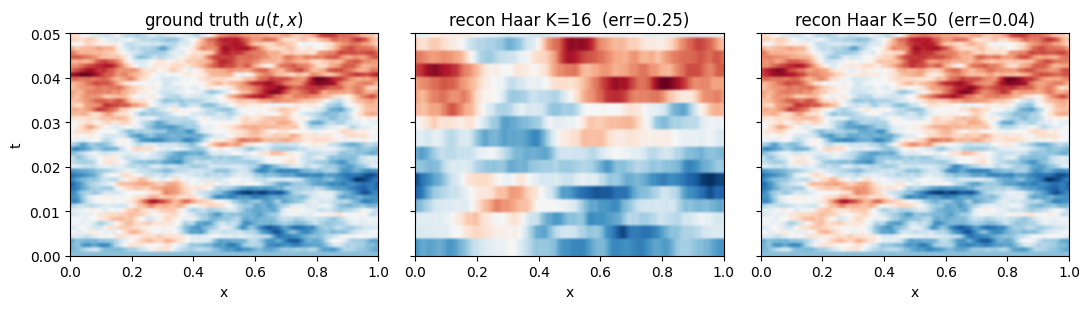

In [8]:
# ============ Paso 4: base de Haar en la grilla temporal de la solución ============
X     = data["X_train"]                    # (N, Nt+1, Nx): soluciones ground truth u(t,x)
s_sol = np.arange(Ntp1) / Nt               # tiempo normalizado [0,1]  (Ntp1 puntos)
print(f"X: {X.shape}  ->  {Ntp1} puntos temporales  (K máximo = {Ntp1})")

def haar_funcs(K, s):
    """Primeras K funciones de Haar (escala + wavelets por nivel) en s ∈ [0,1]."""
    funcs = [np.ones_like(s)]              # función de escala (constante)
    level = 0
    while len(funcs) < K:
        for m in range(2 ** level):
            if len(funcs) >= K:
                break
            a = m / 2**level; b = (m + 1) / 2**level; mid = (a + b) / 2
            psi = np.zeros_like(s)
            psi[(s >= a) & (s < mid)] =  1.0
            psi[(s >= mid) & (s < b)] = -1.0
            funcs.append(psi)
        level += 1
    return np.stack(funcs[:K], axis=1)     # (len(s), K)

def haar_ortonormal(K, s):
    """Base de Haar ortonormalizada en la grilla (descarta funciones degeneradas)."""
    Phi = haar_funcs(K, s)
    Phi = Phi[:, np.linalg.norm(Phi, axis=0) > 1e-12]
    Q, _ = np.linalg.qr(Phi)               # Q^T Q = I
    return Q

# Reconstrucción de UNA muestra a dos resoluciones temporales
i0, ext = 0, [0, L, 0, T]
fig, axs = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
axs[0].imshow(X[i0], aspect="auto", origin="lower", extent=ext, cmap="RdBu_r")
axs[0].set_title("ground truth $u(t,x)$")
for ax, K in zip(axs[1:], [16, 50]):
    Q  = haar_ortonormal(K, s_sol)
    Xr = Q @ (Q.T @ X[i0])                 # (Ntp1, Nx)
    err = np.linalg.norm(X[i0] - Xr) / np.linalg.norm(X[i0])
    ax.imshow(Xr, aspect="auto", origin="lower", extent=ext, cmap="RdBu_r")
    ax.set_title(f"recon Haar K={K}  (err={err:.2f})")
for ax in axs:
    ax.set_xlabel("x")
axs[0].set_ylabel("t"); plt.tight_layout(); plt.show()

K=  1 (rango   1):  E_K = 7.312e-01
K=  2 (rango   2):  E_K = 6.161e-01
K=  4 (rango   4):  E_K = 5.063e-01
K=  8 (rango   8):  E_K = 4.064e-01
K= 16 (rango  16):  E_K = 3.151e-01
K= 24 (rango  24):  E_K = 2.752e-01
K= 32 (rango  32):  E_K = 2.261e-01
K= 40 (rango  40):  E_K = 1.452e-01
K= 48 (rango  48):  E_K = 7.514e-02
K= 51 (rango  51):  E_K = 4.567e-16

Decaimiento  E_K ~ K^(-s)  con  s ≈ 0.37  (Hölder baja: forzamiento blanco en tiempo)
K = 51 (= nº de puntos temporales)  ->  reconstrucción exacta


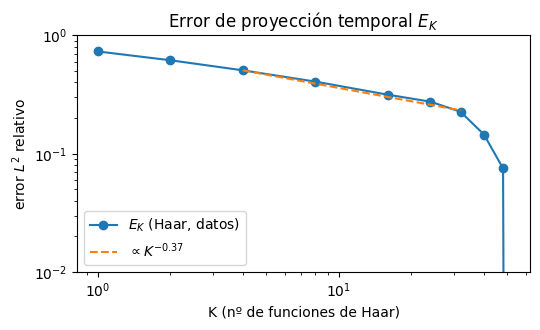

In [9]:
# ============ Error de proyección temporal E_K vs número de modos K ============
def proyectar_haar(K, X):
    Q  = haar_ortonormal(K, s_sol)
    C  = np.einsum("tk,ntx->nkx", Q, X)     # coeficientes C_k(x)  (N, K', Nx)
    Xr = np.einsum("tk,nkx->ntx", Q, C)     # reconstrucción       (N, Ntp1, Nx)
    num = np.linalg.norm((X - Xr).reshape(N, -1), axis=1)
    den = np.linalg.norm(X.reshape(N, -1), axis=1)
    return (num / den).mean(), Q.shape[1]

Ks, EK = [1, 2, 4, 8, 16, 24, 32, 40, 48, 51], []
for K in Ks:
    e, r = proyectar_haar(K, X)
    EK.append(e)
    print(f"K={K:>3} (rango {r:>3}):  E_K = {e:.3e}")

# Ajuste de ley de potencias  E_K ~ K^{-s}  en la zona K=4..32
sel = [(4 <= k <= 32) for k in Ks]
kk  = np.array([k for k, m in zip(Ks, sel) if m], float)
ee  = np.array([e for e, m in zip(EK, sel) if m])
s_exp = -np.polyfit(np.log(kk), np.log(ee), 1)[0]
print(f"\nDecaimiento  E_K ~ K^(-s)  con  s ≈ {s_exp:.2f}  "
      f"(Hölder baja: forzamiento blanco en tiempo)")
print(f"K = {Ntp1} (= nº de puntos temporales)  ->  reconstrucción exacta")

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.loglog(Ks, EK, "o-", label="$E_K$ (Haar, datos)")
ax.loglog(kk, ee[0] * (kk / kk[0]) ** (-s_exp), "--",
          label=fr"$\propto K^{{-{s_exp:.2f}}}$")
ax.set_xlabel("K (nº de funciones de Haar)"); ax.set_ylabel("error $L^2$ relativo")
ax.set_ylim(1e-2, 1); ax.set_title(r"Error de proyección temporal $E_K$")
ax.legend(); plt.tight_layout(); plt.show()

## Paso 5 — Modelo F-SPDENO: backbone FNO

Recreamos la arquitectura del Apéndice F.1 / D.2 para la tarea $W\mapsto X$. El FNO aprende el operador determinista

$$(\chi_0(x),\,\eta(W)) \;\longmapsto\; \{C_k(x)\}_{k=1}^{K},$$

y la solución se reconstruye con la base de Haar fija: $\hat u(t,x)=\sum_{k=1}^K C_k(x)\,\phi_k(t)$.

### ¿Qué es un FNO (Fourier Neural Operator)? — intuición para quien no lo conoce

- Un **operador neuronal** aprende un mapa entre **funciones** (no entre vectores de tamaño fijo). Aquí: de la función de entrada (condición inicial + features del ruido, definidas sobre la grilla espacial) a las funciones de salida $C_k(x)$.
- **Idea central:** una *convolución* (un filtro espacial) equivale a una **multiplicación en el dominio de Fourier** (teorema de convolución). En vez de aprender filtros locales, el FNO aprende directamente unos *multiplicadores* en Fourier.
- Cada **capa de Fourier** hace: `FFT` → quedarse solo con las **frecuencias más bajas** (estructura suave/global; descartar las altas = menos parámetros y robustez a la resolución) → **multiplicar** por pesos (complejos) aprendidos que **mezclan los canales** → `IFFT`. En paralelo, una **rama local** (convolución $1{\times}1$) recupera lo que el filtro de Fourier descarta. Se **suman** y se aplica una no linealidad (GELU).
- **Por qué encaja aquí:** el operador solución de la SPDE en el toro es (aprox.) una **convolución espacial**, justo lo que la capa de Fourier representa con pocos parámetros e independiente de la resolución de la grilla.

### La arquitectura concreta (lo que codificamos abajo)

- **Entrada:** $\chi_0(x)$ (aquí $\equiv 0$) + grilla espacial + features de Wick $\eta(W)$ (escalares, como canales constantes en $x$). El canal de grilla le da al FNO información de posición para poder generar variación espacial.
- **Estructura:** *lifting* (sube a un espacio latente) → 6 *capas de Fourier* (ancho 64, 16 modos) → *projection* (baja a los $K$ canales de salida).
- **Salida:** $K=51$ campos $C_k(x)$ (Haar; máximo sin pérdida en nuestra grilla — el paper usa $K=64$ en una grilla más fina).
- **Entrenamiento (F.1):** $L^2$ relativo, Adam lr $10^{-3}$, batch 64, ReduceLROnPlateau (factor 0.1, paciencia 15), 200 épocas; features de Wick con $M=4$.

In [ ]:
# ============ Datos y tensores de entrada para el FNO (tarea W -> X) ============
# El FNO recibe, en CADA punto x de la grilla, un vector de canales, y devuelve K canales.
# Aquí armamos ese tensor de entrada con forma (B, Nx, canales).
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(0)

Wtr, Xtr = data["W_train"], data["X_train"]    # ruido y solución de entrenamiento
Wte, Xte = data["W_test"],  data["X_test"]     # ... y de test

# Features de Wick (S=2 modos espaciales, Tm=3 temporales, M=4) para train y test.
# Son ESCALARES por trayectoria: P números que resumen el ruido (la función del Paso 3).
Ftr, alphas = construir_features_wick(Wtr, S=2, Tm=3, M=4)
Fte, _      = construir_features_wick(Wte, S=2, Tm=3, M=4)
# Estandarizar (media 0, desv. 1) usando estadísticos del TRAIN: ayuda a la optimización.
mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-8
Ftr, Fte = (Ftr - mu) / sd, (Fte - mu) / sd
P = Ftr.shape[1]

# Base de Haar K=51 (máximo sin pérdida en esta grilla de 51 puntos temporales).
Qh   = haar_ortonormal(Ntp1, s_sol)            # (Ntp1, K)
Kout = Qh.shape[1]

# Construcción del tensor de entrada (B, Nx, canales). Como las features son escalares
# (un valor por trayectoria), se REPITEN ("broadcast") en todos los puntos x -> son
# canales CONSTANTES en el espacio:
#   canal 0     : chi0(x)  (condición inicial; aquí = 0)
#   canal 1     : x        (la grilla espacial; le da al FNO información de posición)
#   canales 2.. : features de Wick eta(W), repetidas en x
def construir_entrada(Fmat):
    n = len(Fmat)
    chi0 = np.zeros((n, Nx, 1), np.float32)                                # (n, Nx, 1)
    grid = np.repeat(x.astype(np.float32)[None, :, None], n, axis=0)       # (n, Nx, 1)
    feat = np.repeat(Fmat[:, None, :].astype(np.float32), Nx, axis=1)      # (n, Nx, P)
    return np.concatenate([chi0, grid, feat], axis=-1)                     # (n, Nx, 2+P)

Xin_tr = torch.tensor(construir_entrada(Ftr))
Xin_te = torch.tensor(construir_entrada(Fte))
Y_tr   = torch.tensor(Xtr.astype(np.float32))  # objetivo: solución u(t,x), forma (B, Ntp1, Nx)
Y_te   = torch.tensor(Xte.astype(np.float32))
Qt     = torch.tensor(Qh.astype(np.float32))   # base de Haar como tensor (para reconstruir)
in_c   = Xin_tr.shape[-1]

print(f"entrada FNO: {tuple(Xin_tr.shape)}  (in_c = 1 chi0 + 1 grilla + {P} Wick = {in_c})")
print(f"salida: {Kout} coeficientes de Haar -> reconstrucción u(t,x) en {Ntp1} pasos")

In [ ]:
# ===================== Backbone FNO 1D (Li et al. 2020) =====================
# Un FNO procesa una función muestreada en la grilla espacial (aquí Nx=128 puntos).
# La pieza clave es la CONVOLUCIÓN ESPECTRAL: en lugar de aprender un filtro local,
# se aprende una multiplicación en el dominio de Fourier (teorema de convolución).

class SpectralConv1d(nn.Module):
    """Capa de convolución espectral 1D.

    Flujo:  x(espacio) --FFT--> X(frecuencia) --x pesos en modos bajos--> --IFFT--> espacio.
    Solo se retienen/aprenden los 'modes' armónicos más bajos (es un filtro pasa-bajos):
      - frecuencias bajas  = estructura suave/global de la señal,
      - descartar las altas = menos parámetros y robustez a la resolución de la grilla.
    """
    def __init__(self, in_c, out_c, modes):
        super().__init__()
        self.modes = modes                       # nº de frecuencias bajas que se conservan
        scale = 1.0 / (in_c * out_c)             # escala de inicialización de los pesos
        # Pesos COMPLEJOS aprendibles. Para cada frecuencia retenida hay una matriz
        # (in_c x out_c) que MEZCLA los canales. Son los únicos parámetros de esta capa.
        self.weight = nn.Parameter(scale * torch.rand(in_c, out_c, modes, dtype=torch.cfloat))

    def forward(self, x):                        # x: (B, C, Nx) = (lote, canales, espacio)
        n = x.shape[-1]
        xft = torch.fft.rfft(x)                  # FFT real -> coef. de Fourier: (B, C, Nx//2+1)
        # Tensor de salida en frecuencia, inicializado en 0: las frecuencias NO retenidas
        # quedan en cero (de ahí el efecto pasa-bajos).
        out = torch.zeros(x.shape[0], self.weight.shape[1], n // 2 + 1, dtype=torch.cfloat)
        m = min(self.modes, xft.shape[-1])       # por si hay menos frecuencias que 'modes'
        # Para cada una de las m frecuencias bajas, mezclar canales con la matriz aprendida.
        #   einsum "bim,iom->bom":  b=lote, i=canal_entrada, o=canal_salida, m=frecuencia.
        out[..., :m] = torch.einsum("bim,iom->bom", xft[..., :m], self.weight[..., :m])
        return torch.fft.irfft(out, n=n)         # IFFT -> de vuelta al espacio: (B, out_c, Nx)


class FNO1d(nn.Module):
    """Apila:  lifting  ->  n_layers capas de Fourier  ->  projection.

    Nota sobre el orden de los ejes (causa común de bugs):
      - las capas Linear esperan los canales AL FINAL   -> (B, Nx, C)
      - la FFT y Conv1d esperan los canales EN EL MEDIO -> (B, C, Nx)
    Por eso aparecen los .permute() para ir de una convención a la otra.
    """
    def __init__(self, in_c, out_c, width=64, modes=16, n_layers=6):
        super().__init__()
        # (1) LIFTING: sube los canales de entrada (chi0 + grilla + Wick) a un espacio
        #     latente de tamaño 'width'. Es puntual: el mismo mapeo lineal en cada punto x.
        self.fc0 = nn.Linear(in_c, width)
        # (2) Cada capa de Fourier tiene DOS ramas en paralelo:
        #     - spec: convolución espectral  -> mezcla GLOBAL vía Fourier
        #     - pw  : convolución 1x1 (lineal LOCAL punto a punto) -> recupera lo que
        #             'spec' descartó al filtrar las frecuencias altas.
        self.spec = nn.ModuleList([SpectralConv1d(width, width, modes) for _ in range(n_layers)])
        self.pw   = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(n_layers)])
        # (3) PROJECTION: baja del espacio latente a los 'out_c' canales de salida (los C_k).
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, out_c)

    def forward(self, x):                        # x: (B, Nx, in_c)
        x = self.fc0(x)                          # lifting        -> (B, Nx, width)
        x = x.permute(0, 2, 1)                   # canales al medio -> (B, width, Nx)
        for sp, w in zip(self.spec, self.pw):
            x = F.gelu(sp(x) + w(x))             # rama global + rama local, luego no linealidad
        x = x.permute(0, 2, 1)                   # canales al final -> (B, Nx, width)
        x = F.gelu(self.fc1(x))                  # projection (1/2)
        return self.fc2(x)                       # (B, Nx, out_c) = campos C_k(x)


def reconstruir(C):
    """Combina los coeficientes espaciales C_k(x) con la base temporal de Haar:
       u(t,x) = sum_k C_k(x) phi_k(t).     C: (B, Nx, K)  ->  u: (B, Ntp1, Nx)."""
    return torch.einsum("bxk,tk->btx", C, Qt)


def rel_l2(pred, Y):
    """Error L2 relativo por muestra, promediado en el lote (la métrica del paper)."""
    num = torch.linalg.norm((pred - Y).reshape(len(Y), -1), dim=1)
    den = torch.linalg.norm(Y.reshape(len(Y), -1), dim=1)
    return (num / den).mean()


net = FNO1d(in_c, Kout, width=64, modes=16, n_layers=6)
print(f"FNO 1D: 6 capas, ancho 64, 16 modos  ->  {sum(p.numel() for p in net.parameters()):,} parámetros")

In [ ]:
# ============ Entrenamiento (Apéndice F.1) ============
# Cadena de predicción:  features -> FNO -> C_k(x) -> reconstruir con Haar -> u(t,x).
# Se minimiza el error L2 relativo entre u(t,x) predicho y el ground truth.
opt   = torch.optim.Adam(net.parameters(), lr=1e-3)
# ReduceLROnPlateau: si el error de test no mejora en 'patience' épocas, baja el lr (x0.1).
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.1, patience=15)
EPOCHS, BS = 200, 64
hist = []
for ep in range(EPOCHS):
    net.train()
    perm = torch.randperm(len(Xin_tr))            # barajar las muestras en cada época
    for i in range(0, len(perm), BS):             # recorrer en mini-batches de tamaño 64
        idx = perm[i:i + BS]
        opt.zero_grad()                           # limpiar gradientes
        pred = reconstruir(net(Xin_tr[idx]))      # forward: FNO + reconstrucción temporal
        loss = rel_l2(pred, Y_tr[idx])            # pérdida L2 relativa
        loss.backward()                           # retropropagación
        opt.step()                                # paso de Adam (actualiza pesos)
    # Evaluación en test al final de cada época (200 muestras, barato)
    net.eval()
    with torch.no_grad():
        e_te = rel_l2(reconstruir(net(Xin_te)), Y_te).item()
    sched.step(e_te); hist.append(e_te)           # el scheduler ajusta el lr según el test
    if ep % 20 == 0 or ep == EPOCHS - 1:
        with torch.no_grad():
            e_tr = rel_l2(reconstruir(net(Xin_tr)), Y_tr).item()
        print(f"época {ep:>3}: train={e_tr:.4f}  test={e_te:.4f}  lr={opt.param_groups[0]['lr']:.1e}")

# Curva de aprendizaje (error de test por época)
fig, ax = plt.subplots(figsize=(5.5, 3.3))
ax.plot(hist); ax.set_yscale("log")
ax.set_xlabel("época"); ax.set_ylabel("error L2 relativo (test)")
ax.set_title("Entrenamiento F-SPDENO"); plt.tight_layout(); plt.show()

In [ ]:
# ============ Evaluación y comparación con la Table 1 del paper ============
net.eval()
with torch.no_grad():
    pred_te = reconstruir(net(Xin_te))
err_te = rel_l2(pred_te, Y_te).item()
print(f"Error L2 relativo de TEST  (W -> X):  {err_te:.4f}")
print(f"Referencia paper (Table 1, F-SPDENO, N=1000, W->X):  0.012")

# Visualizar una muestra de test: ground truth vs predicción vs error
i0, ext = 0, [0, L, 0, T]
gt, pr = Y_te[i0].numpy(), pred_te[i0].numpy()
fig, axs = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, dat, ttl in zip(axs, [gt, pr, gt - pr],
                        ["ground truth $u(t,x)$", "predicción F-SPDENO", "error"]):
    im = ax.imshow(dat, aspect="auto", origin="lower", extent=ext, cmap="RdBu_r")
    ax.set_xlabel("x"); ax.set_title(ttl); fig.colorbar(im, ax=ax)
axs[0].set_ylabel("t"); plt.tight_layout(); plt.show()

## Resumen

Pipeline **F-SPDENO** completo para $\Phi^4_1$ (tarea $W\mapsto X$):

1. **Features de Wick** $\eta(W)$ (Pasos 1–3) — coordenadas gaussianas $\mathcal N(0,1)$ iid + monomios ortonormales, verificados.
2. **Base de Haar + reconstrucción temporal** (Paso 4) — $u\approx\sum_k C_k(x)\phi_k(t)$, error $E_K$ medido.
3. **Backbone FNO** $(\chi_0,\eta(W))\mapsto\{C_k(x)\}$ y reconstrucción (Paso 5) — entrenado con $L^2$ relativo y comparado con la Table 1.

**Notas de fidelidad al paper:**
- $K=51$ (grilla de 51 puntos) vs $K=64$ del paper (requiere grilla temporal más fina).
- $M=4$ (orden de Hermite óptimo del paper); features con $S=2$ modos espaciales y $T_m=3$ temporales.

**Extensiones naturales:**
- Tarea $(X_0,W)\mapsto X$ (CI estocástica), donde el FNO es realmente necesario por la no linealidad en $\chi_0$ — usar `phi41_train_X0Wmap.npz`.
- Regenerar el ground truth con $\Delta t$ más fino para usar $K=64$ como en el paper.